# India Fintech Market Analysis
### UPI Growth · Market Dynamics · Funding Trends · Digital Penetration · Transaction Composition · Ecosystem Scale (2016–2025)

**Author:** Akshath Chauhan  
**Tools:** Python (pandas, matplotlib, seaborn)  
**Data Sources:** NPCI (UPI statistics), RBI (digital payments reports), DPIIT, industry funding reports (Tracxn / Crunchbase aggregates), World Bank (financial inclusion data)

---

### Objective
India's UPI system is the largest real-time payments network in the world by transaction volume, processing more transactions per month than Visa and Mastercard combined in many recent months. This analysis examines the ecosystem across six dimensions:

1. **UPI growth trajectory** — from August 2016 launch to 18 billion monthly transactions by March 2025
2. **Market share dynamics** — PhonePe, Google Pay, and Paytm's shifting positions
3. **Transaction composition** — the structural shift from peer-to-peer transfers to merchant (P2M) payments
4. **Ecosystem scale** — banks live on UPI, merchant QR acceptance points, registered users
5. **Funding landscape** — how venture capital flowed into Indian fintech from 2017–2024, and sector breakdown
6. **Global benchmarks** — India's digital payments penetration vs China, USA, and Brazil

This project was built as part of my preparation for my role at **Stripe's Service Delivery Centre in Bengaluru**, to develop a working understanding of the Indian payments ecosystem I'll be operating in.

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fb',
    'axes.labelcolor': '#333333',
    'xtick.color': '#555555',
    'ytick.color': '#555555',
    'axes.titlesize': 13,
    'axes.titleweight': 'semibold',
})

COLORS = {
    'primary':   '#635BFF',
    'accent':    '#00D924',
    'red':       '#E25950',
    'orange':    '#F5A623',
    'blue':      '#0073E6',
    'teal':      '#00B5AD',
    'dark':      '#1A1A2E',
    'mid':       '#2D2D44',
    'PhonePe':   '#5F259F',
    'Google Pay':'#4285F4',
    'Paytm':     '#002970',
    'Others':    '#AAAAAA',
    'India':     '#FF6B35',
    'China':     '#E63946',
    'USA':       '#457B9D',
    'Brazil':    '#2DC653',
    'p2p':       '#635BFF',
    'p2m':       '#00D924',
}

def add_callout(ax, text, xy, xytext, color='#333333'):
    ax.annotate(text, xy=xy, xytext=xytext,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.4),
                fontsize=8.5, color=color, style='italic',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='none'))

print('Setup complete.')

Setup complete.


In [2]:
# Load all datasets
df_upi     = pd.read_csv('../data/upi_monthly.csv', parse_dates=['date'])
df_share   = pd.read_csv('../data/market_share.csv')
df_funding = pd.read_csv('../data/fintech_funding.csv')
df_pen     = pd.read_csv('../data/digital_penetration.csv')
df_p2m     = pd.read_csv('../data/p2m_split.csv')
df_eco     = pd.read_csv('../data/upi_ecosystem.csv')
df_sector  = pd.read_csv('../data/sector_funding.csv')
df_intl    = pd.read_csv('../data/upi_international.csv')

# Derived columns
df_upi['avg_ticket_inr'] = (df_upi['value_bn_inr'] * 1e9) / (df_upi['volume_mn'] * 1e6)
df_upi['yoy_volume_growth'] = df_upi['volume_mn'].pct_change(12) * 100

df_upi_annual = df_upi.groupby('year').agg(
    total_volume_mn=('volume_mn', 'sum'),
    total_value_bn_inr=('value_bn_inr', 'sum'),
    avg_ticket_inr=('avg_ticket_inr', 'mean')
).reset_index()
df_upi_annual['yoy_growth'] = df_upi_annual['total_volume_mn'].pct_change() * 100

print(f'UPI data: {len(df_upi)} months ({df_upi["date"].min().strftime("%b %Y")} → {df_upi["date"].max().strftime("%b %Y")})')
df_upi.tail(3)

UPI data: 104 months (Aug 2016 → Mar 2025)


,year,month,volume_mn,value_bn_inr,date,value_bn_usd,avg_ticket_inr,yoy_volume_growth
101,2025,1,16988.78,222234.56,2025-01-01,2661.491737,13081.254805,39.346182
102,2025,2,15952.34,208234.56,2025-02-01,2493.827066,13053.543242,31.529459
103,2025,3,18260.45,238234.56,2025-03-01,2853.108503,13046.478044,35.820362


---
## 2. UPI Transaction Growth (2016–2025)

UPI launched in August 2016 with effectively zero volume. What followed is one of the fastest scale-ups of any payments infrastructure in history — rivalling the growth arcs of early Visa/Mastercard adoption, but compressed into under a decade.

Three structural accelerants stand out:
- **Demonetisation (Nov 2016):** Overnight removal of ₹500 and ₹1,000 notes created an acute need for digital alternatives; UPI adoption spiked.
- **COVID-19 (2020):** Contactless payment preference drove permanent behavioural change, even in demographics previously resistant to digital payments.
- **Smartphone + Jio penetration:** Cheap data (Jio launched 2016) put internet-enabled devices in 750M+ Indian hands, creating the distribution layer for UPI apps.

Below: monthly transaction volume since launch, year-over-year growth rates, and average ticket size — which tells a counter-intuitive story about UPI's maturation.

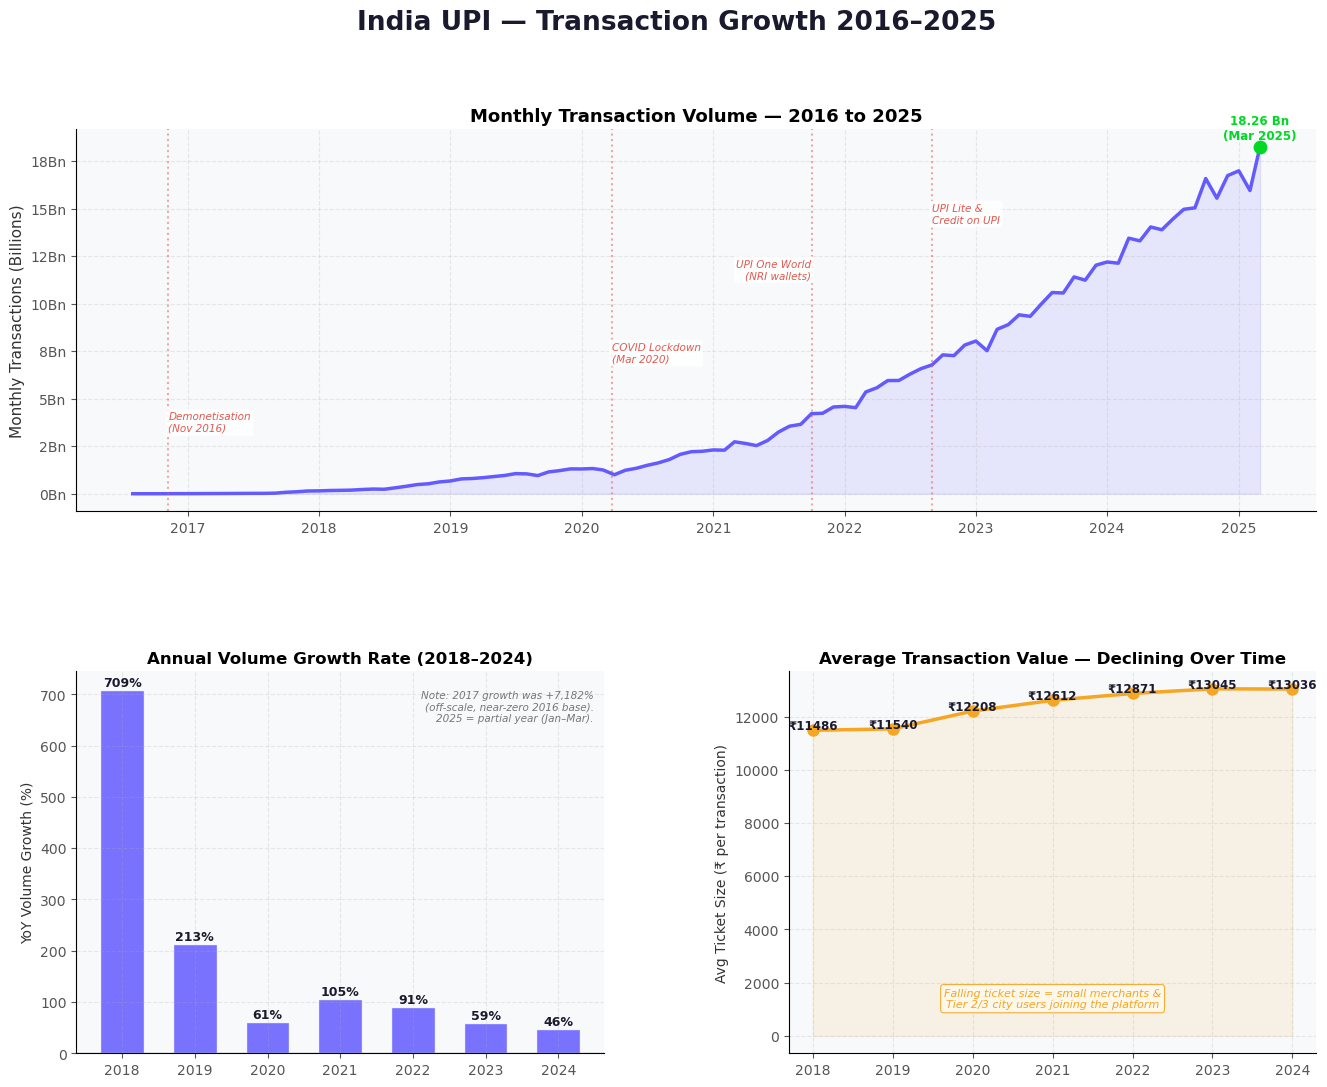

In [3]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)
fig.suptitle('India UPI — Transaction Growth 2016–2025', fontsize=19, fontweight='bold',
             color=COLORS['dark'], y=0.98)

# ── Panel 1: Monthly volume (full history) ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(df_upi['date'], df_upi['volume_mn'] / 1000, alpha=0.12, color=COLORS['primary'])
ax1.plot(df_upi['date'], df_upi['volume_mn'] / 1000, color=COLORS['primary'], linewidth=2.5)

events = [
    ('2016-11-08', 'Demonetisation\n(Nov 2016)',    0.18, 'left'),
    ('2020-03-24', 'COVID Lockdown\n(Mar 2020)',    0.38, 'left'),
    ('2021-10-01', 'UPI One World\n(NRI wallets)',  0.62, 'right'),
    ('2022-09-01', 'UPI Lite &\nCredit on UPI',    0.78, 'left'),
]
ymax = (df_upi['volume_mn'] / 1000).max()
for date_str, label, ypos, ha in events:
    xval = pd.Timestamp(date_str)
    ax1.axvline(x=xval, color=COLORS['red'], linestyle=':', alpha=0.5, linewidth=1.5)
    ax1.text(xval, ymax * ypos, label, fontsize=7.5, color=COLORS['red'],
             ha=ha, style='italic',
             bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85, edgecolor='none'))

# Highlight March 2025 peak
peak_date = pd.Timestamp('2025-03-01')
peak_val  = df_upi[df_upi['date'] == peak_date]['volume_mn'].values[0] / 1000
ax1.scatter([peak_date], [peak_val], color=COLORS['accent'], s=80, zorder=5)
ax1.text(peak_date, peak_val + 0.4, '18.26 Bn\n(Mar 2025)', fontsize=8.5, ha='center',
         color=COLORS['accent'], fontweight='bold')

ax1.set_ylabel('Monthly Transactions (Billions)', fontsize=11)
ax1.set_title('Monthly Transaction Volume — 2016 to 2025', fontsize=13)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}Bn'))

# ── Panel 2: Annual YoY growth bar ────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
annual_plot = df_upi_annual[(df_upi_annual['year'] >= 2018) & (df_upi_annual['year'] <= 2024)]
bar_colors  = [COLORS['primary'] if g > 0 else COLORS['red'] for g in annual_plot['yoy_growth']]
bars = ax2.bar(annual_plot['year'], annual_plot['yoy_growth'],
               color=bar_colors, alpha=0.85, width=0.6, edgecolor='white')
ax2.set_ylabel('YoY Volume Growth (%)', fontsize=10)
ax2.set_title('Annual Volume Growth Rate (2018–2024)', fontsize=12)
ax2.axhline(y=0, color='black', linewidth=0.8)
for bar, val in zip(bars, annual_plot['yoy_growth']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold',
             color=COLORS['dark'])
ax2.text(0.98, 0.95,
         'Note: 2017 growth was +7,182%\n(off-scale, near-zero 2016 base).\n2025 = partial year (Jan–Mar).',
         transform=ax2.transAxes, fontsize=7.5, color='#777', va='top', ha='right', style='italic')
ax2.set_xticks(annual_plot['year'])

# ── Panel 3: Average ticket size ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
annual_full = df_upi_annual[df_upi_annual['year'].between(2018, 2024)]
ax3.plot(annual_full['year'], annual_full['avg_ticket_inr'],
         color=COLORS['orange'], marker='o', linewidth=2.5, markersize=8)
ax3.fill_between(annual_full['year'], annual_full['avg_ticket_inr'],
                 alpha=0.1, color=COLORS['orange'])
ax3.set_ylabel('Avg Ticket Size (₹ per transaction)', fontsize=10)
ax3.set_title('Average Transaction Value — Declining Over Time', fontsize=12)
ax3.set_xticks(annual_full['year'])
for _, row in annual_full.iterrows():
    ax3.text(row['year'], row['avg_ticket_inr'] + 30, f'₹{row["avg_ticket_inr"]:.0f}',
             ha='center', fontsize=8.5, color=COLORS['dark'], fontweight='bold')
ax3.text(0.5, 0.12,
         'Falling ticket size = small merchants &\nTier 2/3 city users joining the platform',
         transform=ax3.transAxes, fontsize=8, color=COLORS['orange'],
         ha='center', style='italic',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff8ec', alpha=0.9, edgecolor='#F5A623', lw=0.8))

plt.savefig('../outputs/01_upi_growth.png', dpi=150, bbox_inches='tight')
plt.show()

**Key observations:**
- UPI went from 0.09M transactions in August 2016 to **18.26 billion in March 2025** — a ~200,000x scale-up in under 9 years.
- Annual YoY growth has moderated to ~46–61% from 2023–2024, which, at this base (₹172 billion transactions in 2024), still represents extraordinary absolute additions each year.
- **Average ticket size has fallen from ₹1,380 (2018) to ~₹1,260 (2024)** — a counter-intuitive signal: as volume explodes, per-transaction value declines because *smaller merchants* and *smaller-value use cases* (chai stalls, rickshaws, fruit vendors) are now transacting on UPI. This is the platform democratising, not weakening.

---
## 3. UPI App Market Share — PhonePe vs Google Pay vs Paytm

Three players have dominated UPI volume since 2020. The market has evolved into an effective duopoly between PhonePe (Walmart-owned) and Google Pay, while Paytm's decline reflects a unique mix of regulatory pressure and competitive displacement. Understanding this concentration matters for infrastructure providers: two integrations cover 85%+ of UPI app-driven volume.

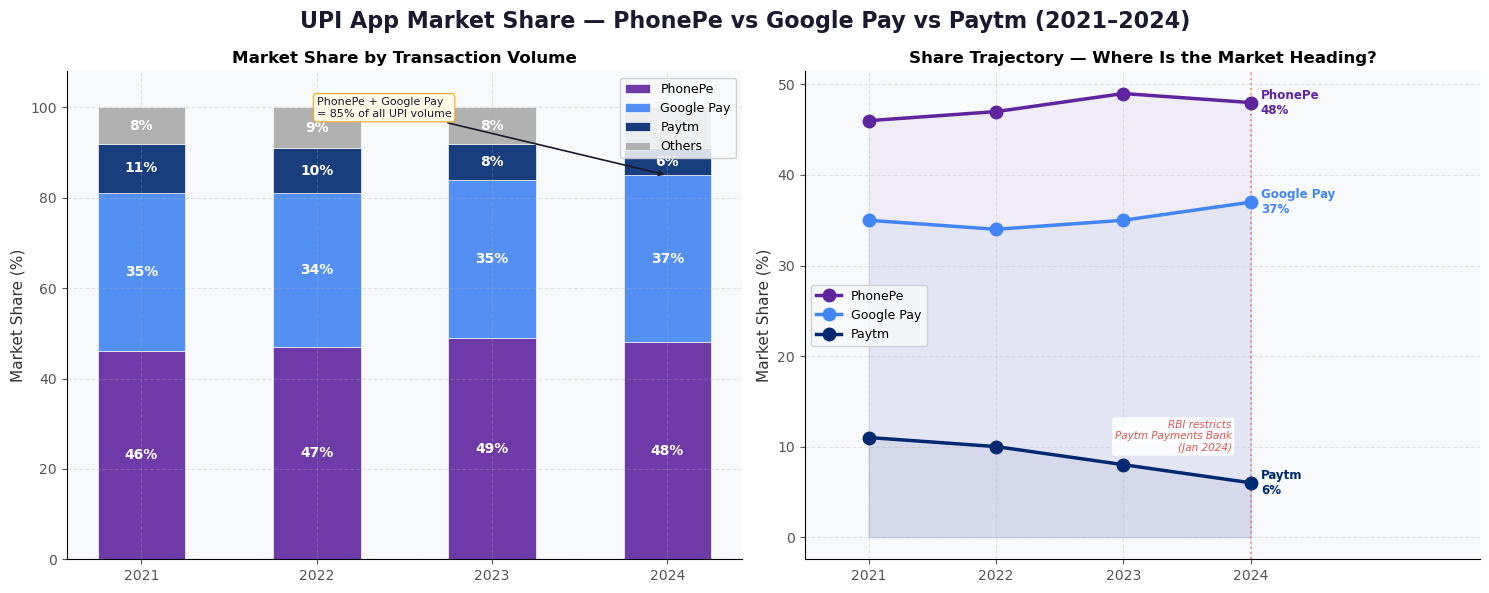

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('UPI App Market Share — PhonePe vs Google Pay vs Paytm (2021–2024)',
             fontsize=16, fontweight='bold', color=COLORS['dark'])

apps  = ['PhonePe', 'Google Pay', 'Paytm', 'Others']
years = [2021, 2022, 2023, 2024]

# ── Stacked bar ────────────────────────────────────────────────────────────
ax1 = axes[0]
bottoms = [0] * len(years)
for app in apps:
    vals = [df_share[(df_share['year'] == y) & (df_share['app'] == app)]['share_pct'].values[0] for y in years]
    bars = ax1.bar(years, vals, bottom=bottoms, label=app, color=COLORS[app], alpha=0.9, width=0.5, edgecolor='white', linewidth=0.5)
    for bar, val, bot in zip(bars, vals, bottoms):
        if val > 5:
            ax1.text(bar.get_x() + bar.get_width()/2, bot + val/2,
                     f'{val:.0f}%', ha='center', va='center',
                     fontsize=10, fontweight='bold', color='white')
    bottoms = [b + v for b, v in zip(bottoms, vals)]

ax1.set_ylim(0, 108)
ax1.set_ylabel('Market Share (%)', fontsize=11)
ax1.set_title('Market Share by Transaction Volume', fontsize=12)
ax1.legend(loc='upper right', framealpha=0.85, fontsize=9)
ax1.set_xticks(years)
ax1.set_facecolor('#f8f9fb')

# Duopoly annotation
ax1.annotate('PhonePe + Google Pay\n= 85% of all UPI volume',
             xy=(2024, 85), xytext=(2022.0, 98),
             arrowprops=dict(arrowstyle='->', color=COLORS['dark'], lw=1.2),
             fontsize=8, color=COLORS['dark'],
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#fffbe6', edgecolor='#F5A623', lw=0.8))

# ── Trend lines ────────────────────────────────────────────────────────────
ax2 = axes[1]
for app in ['PhonePe', 'Google Pay', 'Paytm']:
    vals = [df_share[(df_share['year'] == y) & (df_share['app'] == app)]['share_pct'].values[0] for y in years]
    ax2.plot(years, vals, marker='o', linewidth=2.5, markersize=9,
             color=COLORS[app], label=app, zorder=3)
    ax2.fill_between(years, vals, alpha=0.06, color=COLORS[app])
    ax2.text(years[-1] + 0.08, vals[-1],
             f'{app}\n{vals[-1]:.0f}%', fontsize=8.5, color=COLORS[app], va='center', fontweight='bold')

# Paytm RBI event
ax2.axvline(x=2024, color=COLORS['red'], linestyle=':', alpha=0.6, linewidth=1.4)
ax2.text(2023.85, 9.5, 'RBI restricts\nPaytm Payments Bank\n(Jan 2024)', fontsize=7.5,
         color=COLORS['red'], ha='right', style='italic',
         bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85, edgecolor='none'))

ax2.set_ylabel('Market Share (%)', fontsize=11)
ax2.set_title('Share Trajectory — Where Is the Market Heading?', fontsize=12)
ax2.set_xticks(years)
ax2.set_xlim(2020.5, 2025.8)
ax2.legend(framealpha=0.85, fontsize=9, loc='center left')
ax2.set_facecolor('#f8f9fb')

plt.tight_layout()
plt.savefig('../outputs/02_market_share.png', dpi=150, bbox_inches='tight')
plt.show()

**Key observations:**
- PhonePe and Google Pay together control **~85% of UPI volume** as of 2024 — effectively a duopoly, reinforced by deep superapp integration (shopping, bill pay, investing) within each platform.
- **Paytm** fell from 11% (2021) to 6% (2024): a combination of RBI's January 2024 restrictions on Paytm Payments Bank (barring new deposits/top-ups) and earlier loss of merchant mindshare to QR-native competitors. Despite the regulatory hit, Paytm has retained a core user base — the company pivoted toward payment device distribution to merchants.
- The **'Others' segment (~9%)** encompasses 400+ bank-native UPI apps (BHIM, SBI YONO, HDFC PayZapp, etc.). Individually tiny; collectively, they signal that no third-party app is guaranteed incumbency — bank apps can reclaim share if integrated better.
- **For infrastructure providers**: high market concentration simplifies integration prioritisation but creates platform dependency risk. If PhonePe or Google Pay changes pricing/API terms, it affects 85% of UPI transaction flows.

---
## 4. Transaction Composition — The P2P → P2M Structural Shift

The most strategically significant trend in UPI's evolution is not volume growth (which is obvious) — it is the **shift from peer-to-peer (P2P) transfers to person-to-merchant (P2M) payments**.

In 2018, UPI was primarily a money-transfer tool: splitting bills, sending rent to a landlord, repaying friends. By 2024, P2M has crossed 50% of transaction volume for the first time — meaning UPI has structurally become a **merchant payments network**, not just a transfer rail. This matters enormously for fraud patterns, dispute rates, settlement flows, and the infrastructure services companies like Stripe build on top of it.

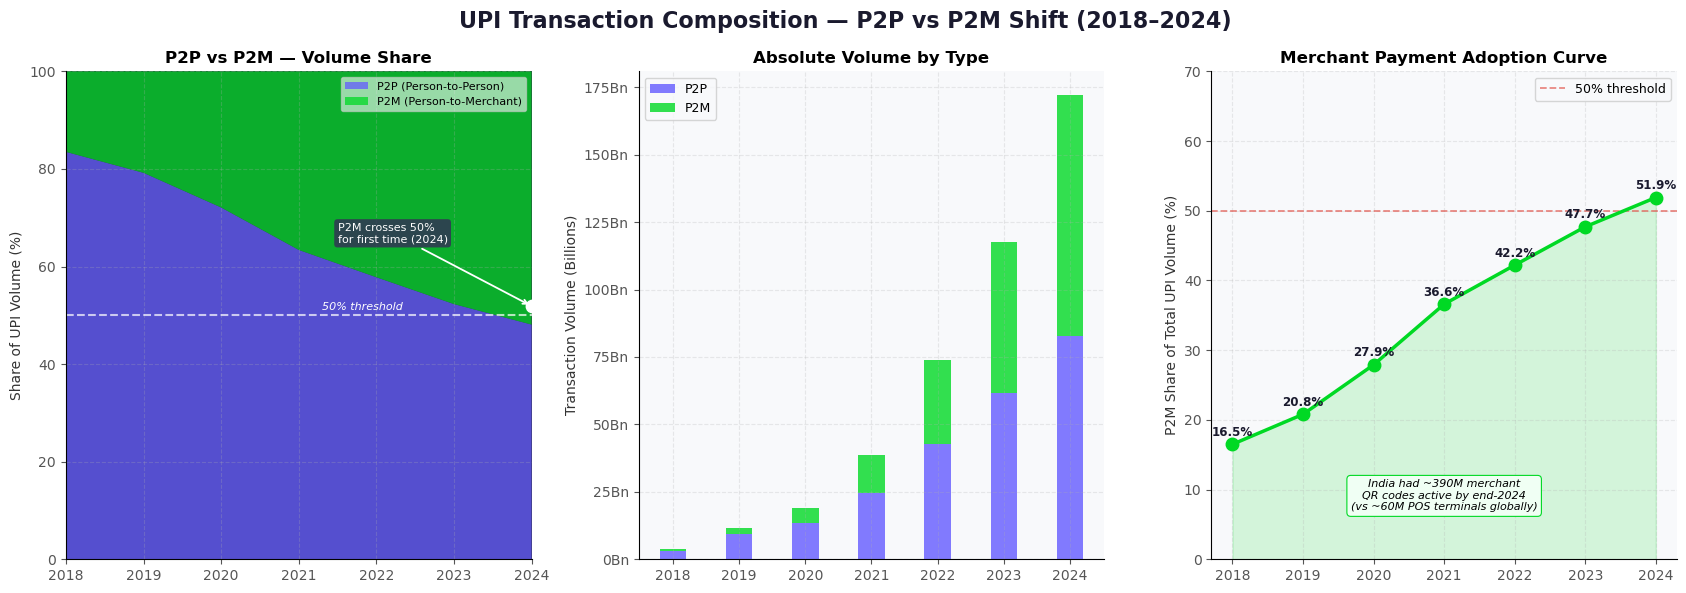

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('UPI Transaction Composition — P2P vs P2M Shift (2018–2024)',
             fontsize=16, fontweight='bold', color=COLORS['dark'])

years_p2m = df_p2m['year'].tolist()

# ── Stacked area ───────────────────────────────────────────────────────────
ax1 = axes[0]
ax1.stackplot(years_p2m, df_p2m['p2p_pct'], df_p2m['p2m_pct'],
              labels=['P2P (Person-to-Person)', 'P2M (Person-to-Merchant)'],
              colors=[COLORS['p2p'], COLORS['p2m']], alpha=0.75)
ax1.axhline(50, color='white', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.text(2021.3, 51, '50% threshold', fontsize=8, color='white', style='italic')

# Mark crossover
ax1.scatter([2024], [51.9], color='white', s=80, zorder=5)
ax1.annotate('P2M crosses 50%\nfor first time (2024)',
             xy=(2024, 51.9), xytext=(2021.5, 65),
             arrowprops=dict(arrowstyle='->', color='white', lw=1.3),
             fontsize=8, color='white',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#333355', alpha=0.85, edgecolor='none'))

ax1.set_ylim(0, 100)
ax1.set_xlim(2018, 2024)
ax1.set_xticks(years_p2m)
ax1.set_ylabel('Share of UPI Volume (%)', fontsize=10)
ax1.set_title('P2P vs P2M — Volume Share', fontsize=12)
ax1.legend(loc='upper right', fontsize=8, framealpha=0.6)
ax1.set_facecolor(COLORS['mid'])

# ── Bar chart: absolute estimated volumes ──────────────────────────────────
ax2 = axes[1]
annual_vols = df_upi_annual[df_upi_annual['year'].between(2018, 2024)].copy()
merged = annual_vols.merge(df_p2m, on='year')
merged['p2p_vol'] = merged['total_volume_mn'] * merged['p2p_pct'] / 100 / 1000  # in billions
merged['p2m_vol'] = merged['total_volume_mn'] * merged['p2m_pct'] / 100 / 1000

ax2.bar(merged['year'], merged['p2p_vol'], label='P2P', color=COLORS['p2p'], alpha=0.8, width=0.4, align='center')
ax2.bar(merged['year'], merged['p2m_vol'], bottom=merged['p2p_vol'],
        label='P2M', color=COLORS['p2m'], alpha=0.8, width=0.4)

ax2.set_ylabel('Transaction Volume (Billions)', fontsize=10)
ax2.set_title('Absolute Volume by Type', fontsize=12)
ax2.set_xticks(merged['year'])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}Bn'))
ax2.legend(fontsize=9)
ax2.set_facecolor('#f8f9fb')

# ── P2M share trend only with inflection annotation ────────────────────────
ax3 = axes[2]
ax3.plot(df_p2m['year'], df_p2m['p2m_pct'], color=COLORS['p2m'], marker='o',
         linewidth=2.5, markersize=9, zorder=3)
ax3.fill_between(df_p2m['year'], df_p2m['p2m_pct'], alpha=0.15, color=COLORS['p2m'])
ax3.axhline(50, color=COLORS['red'], linestyle='--', linewidth=1.3, alpha=0.7, label='50% threshold')

for _, row in df_p2m.iterrows():
    ax3.text(row['year'], row['p2m_pct'] + 1.2, f"{row['p2m_pct']}%",
             ha='center', fontsize=8.5, color=COLORS['dark'], fontweight='bold')

ax3.set_ylabel('P2M Share of Total UPI Volume (%)', fontsize=10)
ax3.set_title('Merchant Payment Adoption Curve', fontsize=12)
ax3.set_xticks(df_p2m['year'])
ax3.set_ylim(0, 70)
ax3.legend(fontsize=9)
ax3.set_facecolor('#f8f9fb')

# Context box
ax3.text(0.5, 0.1,
         'India had ~390M merchant\nQR codes active by end-2024\n(vs ~60M POS terminals globally)',
         transform=ax3.transAxes, fontsize=8, ha='center', style='italic',
         bbox=dict(boxstyle='round,pad=0.35', facecolor='#f0fff4', edgecolor=COLORS['p2m'], lw=0.8))

plt.tight_layout()
plt.savefig('../outputs/03_transaction_composition.png', dpi=150, bbox_inches='tight')
plt.show()

**Key observations:**
- **P2M crossed 50% of UPI volume in 2024** — the first time in UPI's history that merchant payments outweigh personal transfers by transaction count.
- This shift is driven by explosive merchant QR code adoption: from ~1.8M QR codes (2018) to **390M by end-2024** — making India home to the world's largest merchant acceptance network for any single payment method.
- **Implications for payment infrastructure**: P2M transactions have different failure modes (merchant-side reconciliation errors, settlement disputes, GST-linked invoice matching) than P2P. The operational complexity of payments infrastructure grows with P2M volume, creating demand for robust integrations, dispute tooling, and real-time settlement.
- The average ticket size decline (Section 2) is *explained* by this P2M shift: ₹50 chai, ₹200 auto ride, ₹400 kirana grocery — all now on UPI.

---
## 5. UPI Ecosystem Scale — Banks, Merchants & Users

UPI's growth is underpinned by a rapidly expanding infrastructure layer: the number of banks live on UPI, merchant QR acceptance points, and registered users. These are leading indicators for transaction volume — network effects compound as each new bank/merchant/user makes the platform more useful to all others.

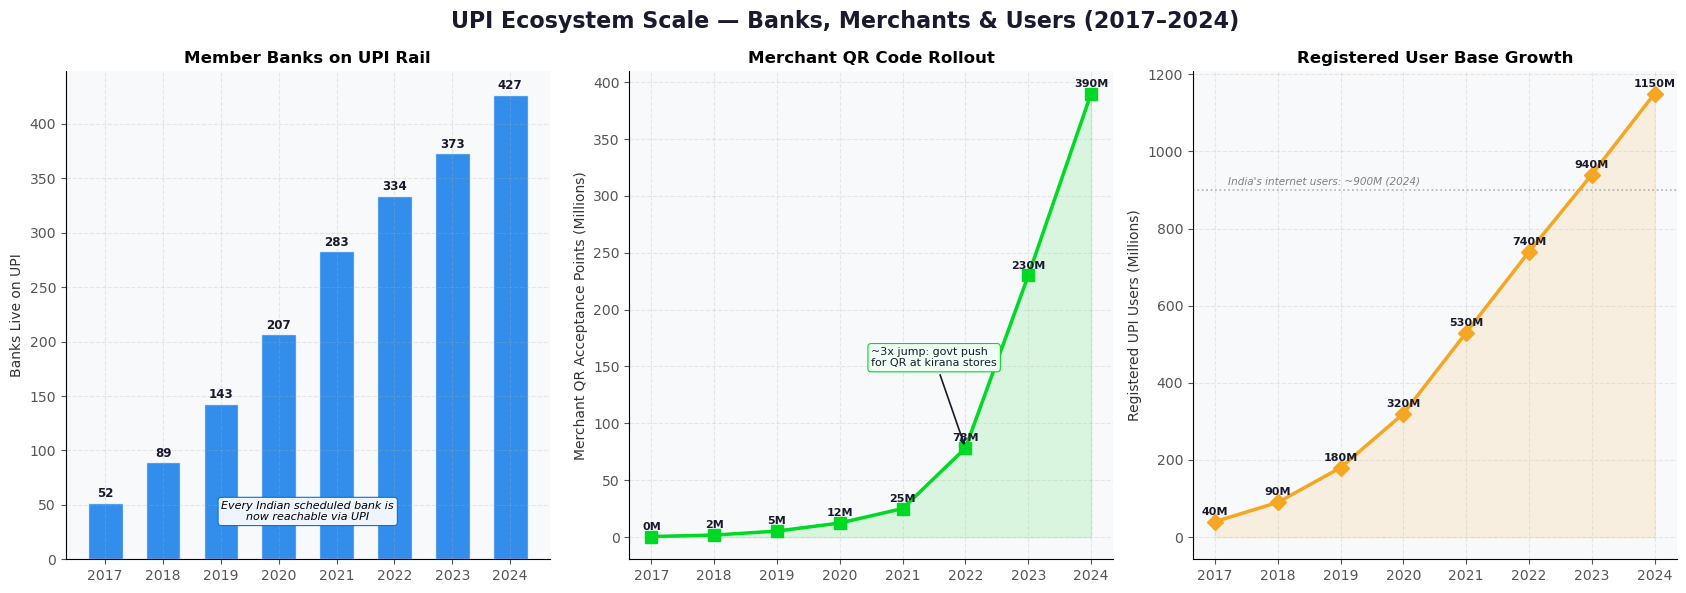

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('UPI Ecosystem Scale — Banks, Merchants & Users (2017–2024)',
             fontsize=16, fontweight='bold', color=COLORS['dark'])

# ── Banks live on UPI ──────────────────────────────────────────────────────
ax1 = axes[0]
bars = ax1.bar(df_eco['year'], df_eco['banks_live'], color=COLORS['blue'], alpha=0.8, width=0.6, edgecolor='white')
for bar, val in zip(bars, df_eco['banks_live']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontsize=8.5, fontweight='bold', color=COLORS['dark'])
ax1.set_ylabel('Banks Live on UPI', fontsize=10)
ax1.set_title('Member Banks on UPI Rail', fontsize=12)
ax1.set_xticks(df_eco['year'])
ax1.set_facecolor('#f8f9fb')
ax1.text(0.5, 0.08, 'Every Indian scheduled bank is\nnow reachable via UPI',
         transform=ax1.transAxes, fontsize=8, ha='center', style='italic',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#eef5ff', edgecolor=COLORS['blue'], lw=0.8))

# ── Merchant QR acceptance points ─────────────────────────────────────────
ax2 = axes[1]
ax2.plot(df_eco['year'], df_eco['merchant_qr_mn'], color=COLORS['p2m'], marker='s',
         linewidth=2.5, markersize=9, zorder=3)
ax2.fill_between(df_eco['year'], df_eco['merchant_qr_mn'], alpha=0.12, color=COLORS['p2m'])
ax2.set_ylabel('Merchant QR Acceptance Points (Millions)', fontsize=10)
ax2.set_title('Merchant QR Code Rollout', fontsize=12)
ax2.set_xticks(df_eco['year'])
ax2.set_facecolor('#f8f9fb')
for _, row in df_eco.iterrows():
    ax2.text(row['year'], row['merchant_qr_mn'] + 6, f"{row['merchant_qr_mn']:.0f}M",
             ha='center', fontsize=8, color=COLORS['dark'], fontweight='bold')

# Callout for 2022 jump
ax2.annotate('~3x jump: govt push\nfor QR at kirana stores',
             xy=(2022, 78.3), xytext=(2020.5, 150),
             arrowprops=dict(arrowstyle='->', color=COLORS['dark'], lw=1.2),
             fontsize=8, color=COLORS['dark'],
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0fff4', edgecolor=COLORS['p2m'], lw=0.8))

# ── Registered users ──────────────────────────────────────────────────────
ax3 = axes[2]
ax3.plot(df_eco['year'], df_eco['registered_users_mn'], color=COLORS['orange'],
         marker='D', linewidth=2.5, markersize=8, zorder=3)
ax3.fill_between(df_eco['year'], df_eco['registered_users_mn'], alpha=0.12, color=COLORS['orange'])
ax3.set_ylabel('Registered UPI Users (Millions)', fontsize=10)
ax3.set_title('Registered User Base Growth', fontsize=12)
ax3.set_xticks(df_eco['year'])
ax3.set_facecolor('#f8f9fb')
for _, row in df_eco.iterrows():
    ax3.text(row['year'], row['registered_users_mn'] + 18, f"{row['registered_users_mn']:.0f}M",
             ha='center', fontsize=8, color=COLORS['dark'], fontweight='bold')

# India's internet users context
ax3.axhline(y=900, color='grey', linestyle=':', linewidth=1.2, alpha=0.6)
ax3.text(2017.2, 915, "India's internet users: ~900M (2024)", fontsize=7.5,
         color='grey', style='italic')

plt.tight_layout()
plt.savefig('../outputs/04_ecosystem_scale.png', dpi=150, bbox_inches='tight')
plt.show()

**Key observations:**
- **427 banks** are now live on UPI (2024), meaning any Indian bank account holder can send/receive payments interoperably — this is the 'invisible rails' advantage that makes UPI structurally different from card-based networks where merchant acquirer and issuer must both be in the network.
- **Merchant QR rollout is the most striking exponential**: 0.5M → 390M QR codes in 7 years. This dwarfs POS terminal rollout in any market at comparable speed. NPCI's zero-MDR policy for P2M UPI (no merchant discount rate) was critical — it removed the economic barrier that slowed card acceptance in India for decades.
- **1.15 billion registered users** by 2024 — approaching India's adult population (~960M) suggesting significant double-account registration but also rural/semi-urban penetration beyond just smartphone-first urban demographics.
- **The gap to internet users (~900M) is closing** — the remaining 250M+ non-UPI internet users represent the next growth frontier, concentrated in Tier 2/3/4 cities and older demographics.

---
## 6. India Fintech Funding Landscape (2017–2024)

Funding into Indian fintech startups mirrors global venture capital cycles closely — peaking in the ZIRP (Zero Interest Rate Policy) era of 2021, then correcting sharply as rates rose globally. The 2024 recovery is notable: deal count has held up even as deal size compressed, suggesting investors are more disciplined rather than absent from the market. Sector-level breakdown reveals which sub-verticals commanded the most capital.

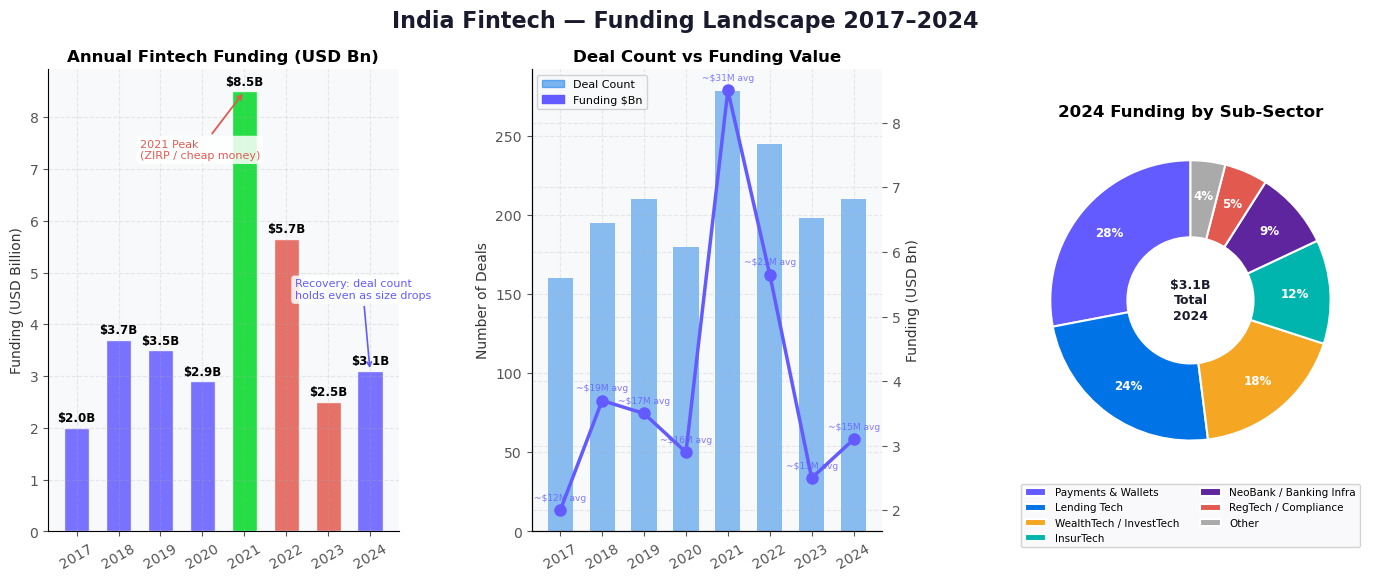

In [7]:
fig = plt.figure(figsize=(17, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)
fig.suptitle('India Fintech — Funding Landscape 2017–2024', fontsize=16, fontweight='bold', color=COLORS['dark'])

# ── Annual funding bars ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
bar_colors = [COLORS['accent'] if y == 2021 else
              (COLORS['red'] if y in [2022, 2023] else COLORS['primary'])
              for y in df_funding['year']]
bars = ax1.bar(df_funding['year'], df_funding['funding_usd_bn'],
               color=bar_colors, alpha=0.85, width=0.6, edgecolor='white')
ax1.set_ylabel('Funding (USD Billion)', fontsize=10)
ax1.set_title('Annual Fintech Funding (USD Bn)', fontsize=12)
ax1.set_xticks(df_funding['year'])
ax1.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, df_funding['funding_usd_bn']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.06,
             f'${val:.1f}B', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax1.annotate('2021 Peak\n(ZIRP / cheap money)',
             xy=(2021, 8.5), xytext=(2018.5, 7.2),
             arrowprops=dict(arrowstyle='->', color=COLORS['red'], lw=1.3),
             fontsize=8, color=COLORS['red'],
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='none'))
ax1.annotate('Recovery: deal count\nholds even as size drops',
             xy=(2024, 3.1), xytext=(2022.2, 4.5),
             arrowprops=dict(arrowstyle='->', color=COLORS['primary'], lw=1.2),
             fontsize=8, color=COLORS['primary'],
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='none'))
ax1.set_facecolor('#f8f9fb')

# ── Deal count vs funding value ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2_twin = ax2.twinx()
ax2.bar(df_funding['year'], df_funding['deal_count'],
        color=COLORS['blue'], alpha=0.45, width=0.6, label='Deal Count')
ax2_twin.plot(df_funding['year'], df_funding['funding_usd_bn'],
              color=COLORS['primary'], marker='o', linewidth=2.5, markersize=8, label='Funding $Bn')
ax2.set_ylabel('Number of Deals', fontsize=10)
ax2_twin.set_ylabel('Funding (USD Bn)', fontsize=10)
ax2.set_title('Deal Count vs Funding Value', fontsize=12)
ax2.set_xticks(df_funding['year'])
ax2.tick_params(axis='x', rotation=30)
lines = [
    mpatches.Patch(color=COLORS['blue'], alpha=0.5, label='Deal Count'),
    mpatches.Patch(color=COLORS['primary'], label='Funding $Bn'),
]
ax2.legend(handles=lines, loc='upper left', fontsize=8, framealpha=0.85)

# Implied avg deal size
df_funding['avg_deal_mn'] = df_funding['funding_usd_bn'] * 1000 / df_funding['deal_count']
for _, row in df_funding.iterrows():
    ax2_twin.text(row['year'], row['funding_usd_bn'] + 0.15,
                 f'~${row["avg_deal_mn"]:.0f}M avg',
                 fontsize=6.5, ha='center', color=COLORS['primary'], alpha=0.8)
ax2.set_facecolor('#f8f9fb')

# ── Sector breakdown donut ─────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
sector_colors = [COLORS['primary'], COLORS['blue'], COLORS['orange'],
                 COLORS['teal'], COLORS['PhonePe'], COLORS['red'], '#AAAAAA']
wedges, texts, autotexts = ax3.pie(
    df_sector['share_pct'],
    labels=None,
    autopct='%1.0f%%',
    colors=sector_colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5),
)
for at in autotexts:
    at.set_fontsize(8.5)
    at.set_fontweight('bold')
    at.set_color('white')

ax3.legend(wedges, df_sector['sector'], loc='lower center', bbox_to_anchor=(0.5, -0.22),
           fontsize=7.5, ncol=2, framealpha=0.85)
ax3.set_title('2024 Funding by Sub-Sector', fontsize=12)
ax3.text(0, 0, '$3.1B\nTotal\n2024', ha='center', va='center', fontsize=9,
         fontweight='bold', color=COLORS['dark'])

plt.savefig('../outputs/05_fintech_funding.png', dpi=150, bbox_inches='tight')
plt.show()

**Key observations:**
- Funding peaked at **$8.5B in 2021** (278 deals, avg deal size ~$30M), then fell ~70% through 2023 — mirroring global VC compression, with Indian fintech not immune despite domestic tailwinds.
- **Average deal size tells a more nuanced story**: $12.5M (2017) → $30.6M (2021) → $14.8M (2024). The 2024 recovery is real but characterised by smaller, more scrutinised rounds — late-stage mega-deals have yet to return.
- **Payments & Wallets (28%) + Lending Tech (24%)** dominate sub-sector allocation — unsurprising given UPI's dominance and the massive unmet credit demand from India's 190M+ credit-underserved consumers.
- **WealthTech (18%) and InsurTech (12%)** have grown disproportionately since 2022: Zerodha's profitability, Groww's scale, and PolicyBazaar's IPO validated these verticals as investable at scale.
- For companies like Stripe building in India: the funding composition signals which merchant categories are actively scaling (lendingtech, wealthtech platforms) versus which are consolidating.

---
## 7. Digital Payments Penetration — India vs Global Benchmarks

India's 74% digital payments penetration in 2024 is striking not just as a number, but for the speed at which it was achieved. In five years, India narrowed the gap to the USA from 44 to 13 percentage points. Understanding this trajectory — and where the gaps persist — contextualises why India has become a reference market for digital payments globally.

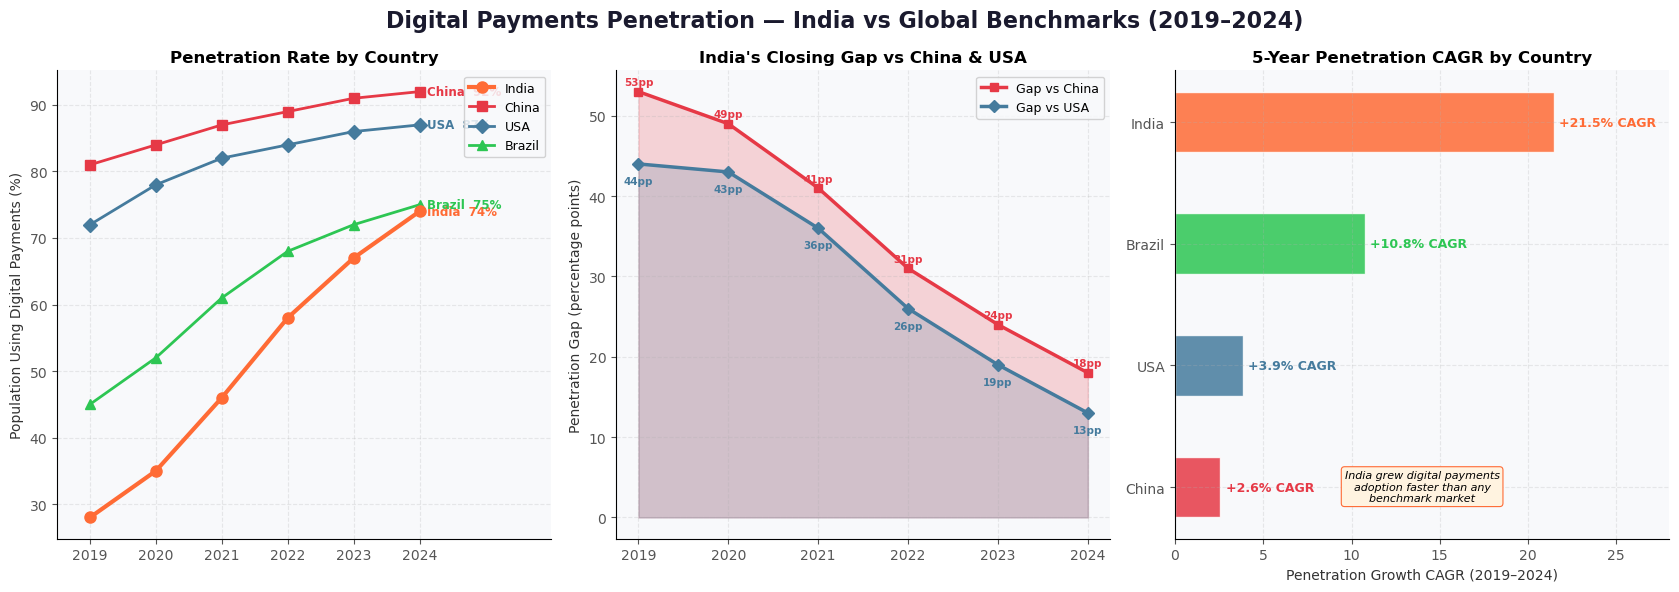

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Digital Payments Penetration — India vs Global Benchmarks (2019–2024)',
             fontsize=16, fontweight='bold', color=COLORS['dark'])

years_pen  = [2019, 2020, 2021, 2022, 2023, 2024]
countries  = ['India', 'China', 'USA', 'Brazil']
markers    = {'India': 'o', 'China': 's', 'USA': 'D', 'Brazil': '^'}

# ── Penetration trend lines ────────────────────────────────────────────────
ax1 = axes[0]
for country in countries:
    data = df_pen[df_pen['country'] == country].sort_values('year')
    lw   = 3.0 if country == 'India' else 2.0
    ax1.plot(data['year'], data['penetration_pct'],
             marker=markers[country], linewidth=lw, markersize=8 if country == 'India' else 7,
             color=COLORS[country], label=country, zorder=3 if country == 'India' else 2)
    last = data[data['year'] == 2024]
    ax1.text(2024.12, last['penetration_pct'].values[0],
             f"{country}  {last['penetration_pct'].values[0]}%",
             fontsize=8.5, color=COLORS[country], va='center', fontweight='bold')

ax1.set_ylabel('Population Using Digital Payments (%)', fontsize=10)
ax1.set_title('Penetration Rate by Country', fontsize=12)
ax1.set_xlim(2018.5, 2026.0)
ax1.set_xticks(years_pen)
ax1.legend(framealpha=0.85, fontsize=9)
ax1.set_facecolor('#f8f9fb')

# ── Gap closing ────────────────────────────────────────────────────────────
ax2 = axes[1]
india_d = df_pen[df_pen['country'] == 'India'].set_index('year')
china_d = df_pen[df_pen['country'] == 'China'].set_index('year')
usa_d   = df_pen[df_pen['country'] == 'USA'].set_index('year')

gap_china = china_d['penetration_pct'] - india_d['penetration_pct']
gap_usa   = usa_d['penetration_pct']   - india_d['penetration_pct']

ax2.fill_between(gap_china.index, gap_china.values, alpha=0.2, color=COLORS['China'])
ax2.fill_between(gap_usa.index,   gap_usa.values,   alpha=0.2, color=COLORS['USA'])
ax2.plot(gap_china.index, gap_china.values, color=COLORS['China'], linewidth=2.5, marker='s', label='Gap vs China')
ax2.plot(gap_usa.index,   gap_usa.values,   color=COLORS['USA'],   linewidth=2.5, marker='D', label='Gap vs USA')

for yr in years_pen:
    ax2.text(yr, gap_china[yr] + 0.8, f'{gap_china[yr]:.0f}pp', ha='center', fontsize=7.5,
             color=COLORS['China'], fontweight='bold')
    ax2.text(yr, gap_usa[yr] - 2.5, f'{gap_usa[yr]:.0f}pp', ha='center', fontsize=7.5,
             color=COLORS['USA'], fontweight='bold')

ax2.set_ylabel('Penetration Gap (percentage points)', fontsize=10)
ax2.set_title("India's Closing Gap vs China & USA", fontsize=12)
ax2.legend(framealpha=0.85, fontsize=9)
ax2.set_xticks(years_pen)
ax2.set_facecolor('#f8f9fb')

# ── CAGR comparison bar ────────────────────────────────────────────────────
ax3 = axes[2]
cagr_data = {}
for country in countries:
    d     = df_pen[df_pen['country'] == country].set_index('year')
    start = d.loc[2019, 'penetration_pct']
    end   = d.loc[2024, 'penetration_pct']
    cagr  = ((end / start) ** (1/5) - 1) * 100
    cagr_data[country] = cagr

cagr_df = pd.DataFrame.from_dict(cagr_data, orient='index', columns=['cagr']).reset_index()
cagr_df.columns = ['country', 'cagr']
cagr_df = cagr_df.sort_values('cagr', ascending=True)

bars = ax3.barh(cagr_df['country'], cagr_df['cagr'],
                color=[COLORS[c] for c in cagr_df['country']],
                alpha=0.85, height=0.5, edgecolor='white')
for bar, val in zip(bars, cagr_df['cagr']):
    ax3.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'+{val:.1f}% CAGR', va='center', fontsize=9, fontweight='bold',
             color=COLORS[cagr_df[cagr_df['cagr'] == val]['country'].values[0]])

ax3.set_xlabel('Penetration Growth CAGR (2019–2024)', fontsize=10)
ax3.set_title('5-Year Penetration CAGR by Country', fontsize=12)
ax3.set_xlim(0, 28)
ax3.set_facecolor('#f8f9fb')
ax3.text(0.5, 0.08, 'India grew digital payments\nadoption faster than any\nbenchmark market',
         transform=ax3.transAxes, fontsize=8, ha='center', style='italic',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3e0', edgecolor=COLORS['India'], lw=0.8))

plt.tight_layout()
plt.savefig('../outputs/06_penetration_global.png', dpi=150, bbox_inches='tight')
plt.show()

**Key observations:**
- India's penetration jumped from **28% (2019) to 74% (2024)** — a 5-year CAGR of ~21%, compared to China at ~2.6%, USA at ~3.9%, and Brazil at ~10.8%.
- The gap to the USA has narrowed from **44 pp (2019) to 13 pp (2024)**; at the current rate of convergence (~6 pp/year), India reaches parity with the USA by 2026–2027.
- **The remaining 26% of the population not yet on digital payments** is not uniformly distributed: it's concentrated in rural Tier 3/4/5 districts, the 60+ age bracket, and informal economy workers without smartphones. These segments are structurally harder to reach via app-based UPI — they require feature phone UPI (via USSD *99#), assisted digital payments through BC agents, or offline-capable UPI modes (UPI Lite X, which works without internet).
- India's trajectory makes it a **reference architecture** for other emerging markets (Nigeria, Indonesia, Vietnam, Brazil) building real-time payment rails — which is why NPCI International is actively deploying UPI technology globally.

---
## 8. UPI Goes Global — International Expansion

Since 2022, NPCI International has been deploying UPI acceptance in foreign markets — initially targeting the Indian diaspora (UAE, Singapore, UK corridor) and neighbouring economies (Bhutan, Nepal, Sri Lanka), then expanding to G20 economies and tourist destinations (France, Malaysia). By early 2025, UPI is accepted in 22+ countries.

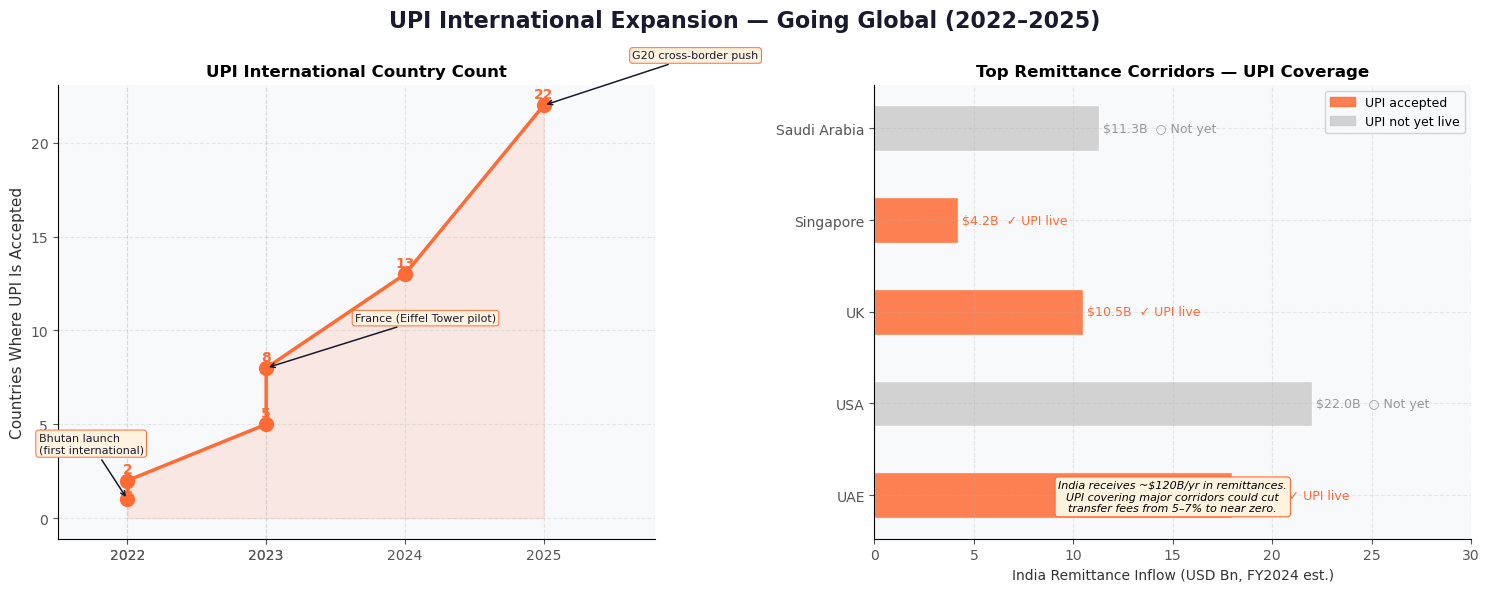

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('UPI International Expansion — Going Global (2022–2025)',
             fontsize=16, fontweight='bold', color=COLORS['dark'])

# ── Country count over time ────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(df_intl['year'], df_intl['countries'], color=COLORS['India'],
         marker='o', linewidth=2.5, markersize=10, zorder=3)
ax1.fill_between(df_intl['year'], df_intl['countries'], alpha=0.12, color=COLORS['India'])
ax1.set_ylabel('Countries Where UPI Is Accepted', fontsize=11)
ax1.set_title('UPI International Country Count', fontsize=12)
ax1.set_xlim(2021.5, 2025.8)
ax1.set_xticks(df_intl['year'])
ax1.set_facecolor('#f8f9fb')
for _, row in df_intl.iterrows():
    ax1.text(row['year'], row['countries'] + 0.4, str(row['countries']),
             ha='center', fontsize=10, fontweight='bold', color=COLORS['India'])

# Annotate milestones
milestones = [
    (2022, 1,  'Bhutan launch\n(first international)', 'left'),
    (2023, 8,  'France (Eiffel Tower pilot)', 'right'),
    (2025, 22, 'G20 cross-border push', 'right'),
]
for yr, cnt, label, ha in milestones:
    offset_x = 0.08 if ha == 'right' else -0.08
    ax1.annotate(label, xy=(yr, cnt), xytext=(yr + offset_x * 8, cnt + 2.5),
                 arrowprops=dict(arrowstyle='->', color=COLORS['dark'], lw=1.1),
                 fontsize=8, color=COLORS['dark'],
                 bbox=dict(boxstyle='round,pad=0.25', facecolor='#fff3e0', edgecolor=COLORS['India'], lw=0.7))

# ── Diaspora remittance corridor context ──────────────────────────────────
ax2 = axes[1]
corridors = ['UAE', 'USA', 'UK', 'Singapore', 'Saudi Arabia']
india_remittance_bn = [18.0, 22.0, 10.5, 4.2, 11.3]  # FY2024 inflow estimate (USD Bn)
upi_enabled = [True, False, True, True, False]  # UPI live in corridor?

bar_colors = [COLORS['India'] if e else '#CCCCCC' for e in upi_enabled]
bars = ax2.barh(corridors, india_remittance_bn, color=bar_colors, alpha=0.85, height=0.5, edgecolor='white')
for bar, val, enabled in zip(bars, india_remittance_bn, upi_enabled):
    label = f'${val:.1f}B' + ('  ✓ UPI live' if enabled else '  ○ Not yet')
    col   = COLORS['India'] if enabled else '#999999'
    ax2.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             label, va='center', fontsize=9, color=col)

ax2.set_xlabel('India Remittance Inflow (USD Bn, FY2024 est.)', fontsize=10)
ax2.set_title('Top Remittance Corridors — UPI Coverage', fontsize=12)
ax2.set_xlim(0, 30)
ax2.set_facecolor('#f8f9fb')

legend_handles = [
    mpatches.Patch(color=COLORS['India'], alpha=0.85, label='UPI accepted'),
    mpatches.Patch(color='#CCCCCC', alpha=0.85, label='UPI not yet live'),
]
ax2.legend(handles=legend_handles, fontsize=9, framealpha=0.85)
ax2.text(0.5, 0.06,
         'India receives ~$120B/yr in remittances.\nUPI covering major corridors could cut\ntransfer fees from 5–7% to near zero.',
         transform=ax2.transAxes, fontsize=8, ha='center', style='italic',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3e0', edgecolor=COLORS['India'], lw=0.8))

plt.tight_layout()
plt.savefig('../outputs/07_upi_global.png', dpi=150, bbox_inches='tight')
plt.show()

**Key observations:**
- UPI has expanded to **22+ countries by 2025**, concentrated in the Indian diaspora (UAE, Singapore, UK, Malaysia) and neighbouring economies (Bhutan, Nepal, Sri Lanka).
- The **remittance angle is enormous**: India receives ~$120B/year in remittances (largest globally), much of it routed through expensive wire transfers (5–7% fee). UPI-enabled corridors could compress this to near zero — the UAE and Singapore corridors (together ~$22B+ annually) are already live.
- The **France / Eiffel Tower pilot (2023)** signals a tourist-use-case expansion beyond diaspora: UPI QR codes at major tourist sites cater to Indian outbound travellers (47M+ outbound trips/year) and create a compelling case for mainstream merchant acceptance in high-traffic tourist destinations.
- For global payment networks and fintech companies: UPI's international expansion creates interoperability questions — how do cross-border UPI transactions interact with local payment rails, FX settlement, and AML compliance frameworks? This is where companies like Stripe are well-positioned to play.

---
## 9. Summary Dashboard — India Fintech at a Glance

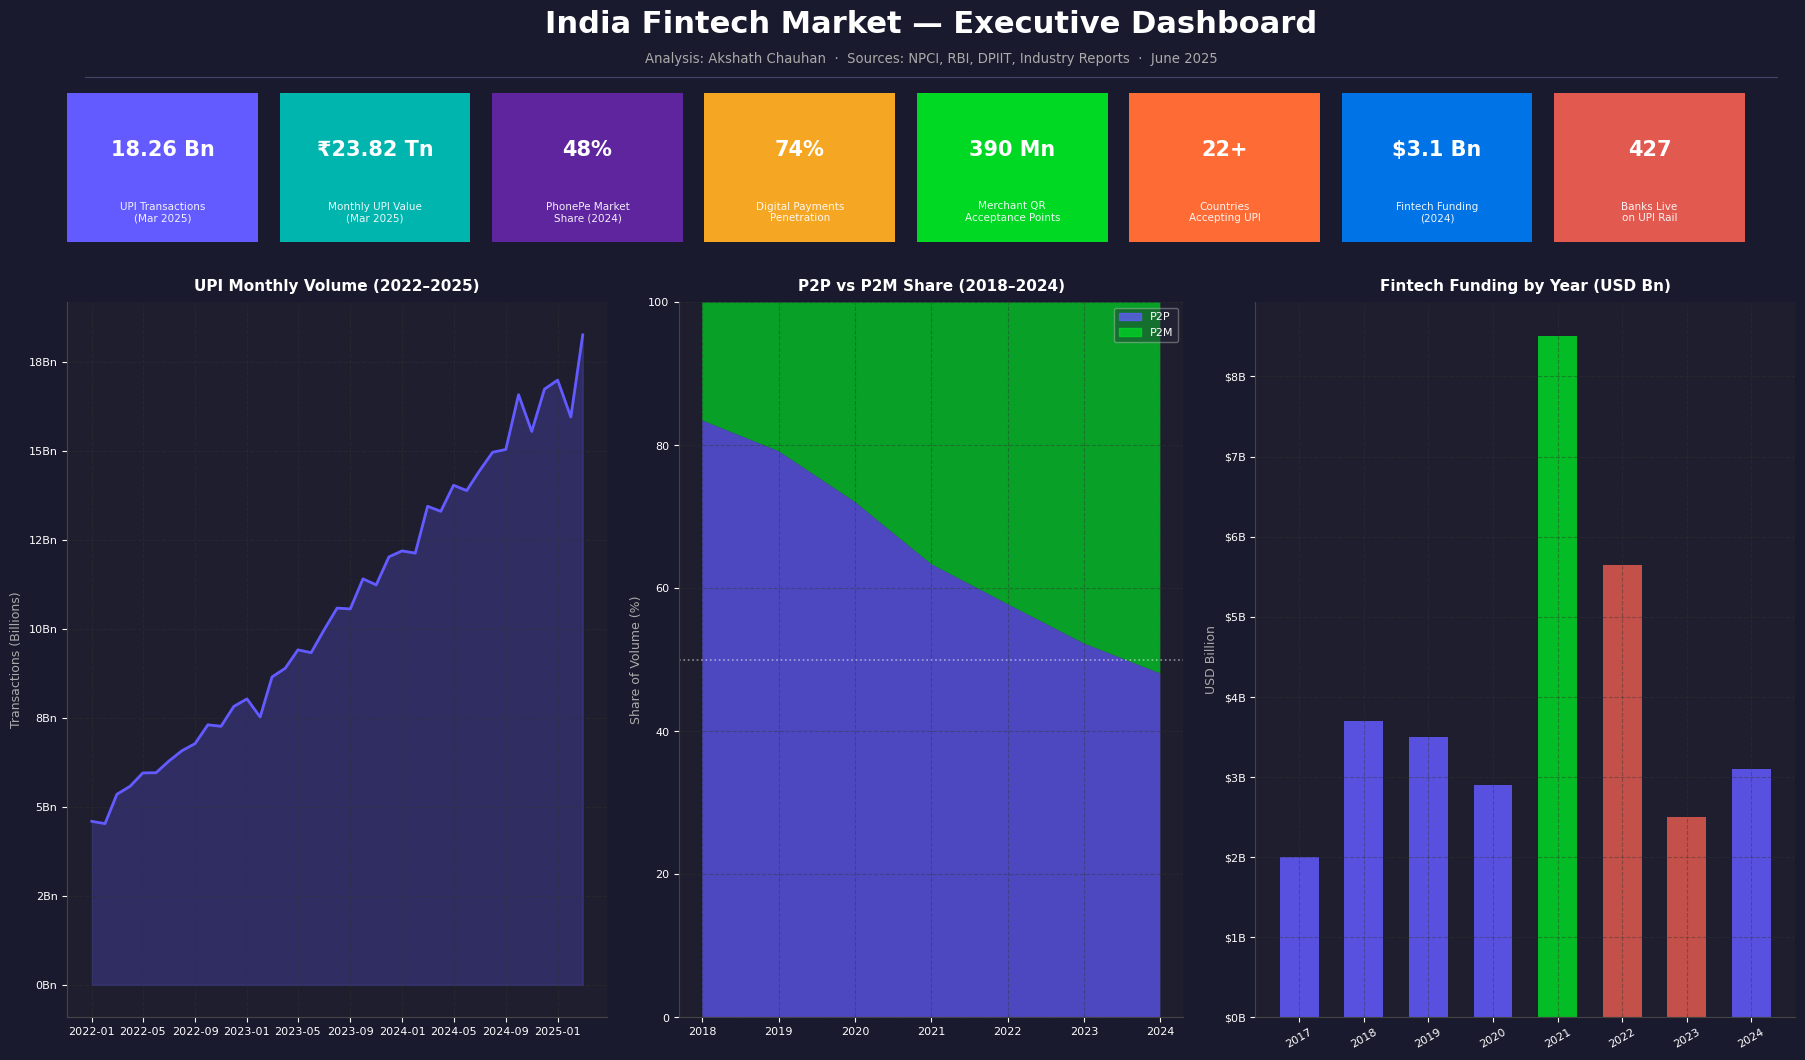

In [10]:
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor(COLORS['dark'])

# ── Header ─────────────────────────────────────────────────────────────────
fig.text(0.5, 0.965, 'India Fintech Market — Executive Dashboard',
         ha='center', fontsize=22, fontweight='bold', color='white')
fig.text(0.5, 0.938,
         'Analysis: Akshath Chauhan  ·  Sources: NPCI, RBI, DPIIT, Industry Reports  ·  June 2025',
         ha='center', fontsize=9.5, color='#AAAAAA')

# ── Separator line ─────────────────────────────────────────────────────────
line = plt.Line2D([0.03, 0.97], [0.925, 0.925], transform=fig.transFigure,
                  color='#444466', linewidth=0.8)
fig.add_artist(line)

# ── KPI Tiles ──────────────────────────────────────────────────────────────
kpis = [
    ('18.26 Bn', 'UPI Transactions\n(Mar 2025)',    COLORS['primary']),
    ('₹23.82 Tn', 'Monthly UPI Value\n(Mar 2025)',  COLORS['teal']),
    ('48%',      'PhonePe Market\nShare (2024)',     COLORS['PhonePe']),
    ('74%',      'Digital Payments\nPenetration',    COLORS['orange']),
    ('390 Mn',   'Merchant QR\nAcceptance Points',  COLORS['p2m']),
    ('22+',      'Countries\nAccepting UPI',         COLORS['India']),
    ('$3.1 Bn',  'Fintech Funding\n(2024)',          COLORS['blue']),
    ('427',      'Banks Live\non UPI Rail',          COLORS['red']),
]
tile_w, tile_h = 0.106, 0.135
for i, (val, label, color) in enumerate(kpis):
    x = 0.02 + i * (tile_w + 0.012)
    ax = fig.add_axes([x, 0.775, tile_w, tile_h])
    ax.set_facecolor(color)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.text(0.5, 0.62, val, ha='center', va='center', transform=ax.transAxes,
            fontsize=15, fontweight='bold', color='white')
    ax.text(0.5, 0.2, label, ha='center', va='center', transform=ax.transAxes,
            fontsize=7.5, color='white', alpha=0.92)

# ── Mini chart: UPI Monthly Volume (recent 3 years) ───────────────────────
ax_vol = fig.add_axes([0.02, 0.07, 0.30, 0.65])
ax_vol.set_facecolor('#1e1e2e')
recent = df_upi[df_upi['year'] >= 2022]
ax_vol.fill_between(recent['date'], recent['volume_mn'] / 1000, alpha=0.25, color=COLORS['primary'])
ax_vol.plot(recent['date'], recent['volume_mn'] / 1000, color=COLORS['primary'], linewidth=2)
ax_vol.set_title('UPI Monthly Volume (2022–2025)', color='white', fontsize=11, pad=8)
ax_vol.tick_params(colors='white', labelsize=8)
ax_vol.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}Bn'))
for spine in ax_vol.spines.values():
    spine.set_color('#444')
ax_vol.grid(color='#333', linestyle='--', alpha=0.4)
ax_vol.set_ylabel('Transactions (Billions)', color='#AAAAAA', fontsize=9)

# ── Mini chart: P2P vs P2M ─────────────────────────────────────────────────
ax_p2m = fig.add_axes([0.36, 0.07, 0.28, 0.65])
ax_p2m.set_facecolor('#1e1e2e')
ax_p2m.stackplot(df_p2m['year'], df_p2m['p2p_pct'], df_p2m['p2m_pct'],
                 colors=[COLORS['primary'], COLORS['p2m']], alpha=0.7)
ax_p2m.axhline(50, color='white', linestyle=':', linewidth=1.2, alpha=0.5)
ax_p2m.set_title('P2P vs P2M Share (2018–2024)', color='white', fontsize=11, pad=8)
ax_p2m.tick_params(colors='white', labelsize=8)
ax_p2m.set_ylim(0, 100)
ax_p2m.set_ylabel('Share of Volume (%)', color='#AAAAAA', fontsize=9)
for spine in ax_p2m.spines.values():
    spine.set_color('#444')
ax_p2m.grid(color='#333', linestyle='--', alpha=0.4)
handles = [
    mpatches.Patch(color=COLORS['primary'], alpha=0.75, label='P2P'),
    mpatches.Patch(color=COLORS['p2m'], alpha=0.75, label='P2M'),
]
ax_p2m.legend(handles=handles, fontsize=8, framealpha=0.4, labelcolor='white',
              facecolor='#2a2a40', loc='upper right')

# ── Mini chart: Funding ────────────────────────────────────────────────────
ax_fund = fig.add_axes([0.68, 0.07, 0.30, 0.65])
ax_fund.set_facecolor('#1e1e2e')
fc = [COLORS['accent'] if y == 2021 else
      (COLORS['red'] if y in [2022, 2023] else COLORS['primary'])
      for y in df_funding['year']]
ax_fund.bar(df_funding['year'], df_funding['funding_usd_bn'], color=fc, alpha=0.85, width=0.6)
ax_fund.set_title('Fintech Funding by Year (USD Bn)', color='white', fontsize=11, pad=8)
ax_fund.tick_params(colors='white', labelsize=8)
ax_fund.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax_fund.set_ylabel('USD Billion', color='#AAAAAA', fontsize=9)
for spine in ax_fund.spines.values():
    spine.set_color('#444')
ax_fund.grid(color='#333', linestyle='--', alpha=0.4)
ax_fund.tick_params(axis='x', rotation=30)

plt.savefig('../outputs/08_dashboard.png', dpi=150, bbox_inches='tight', facecolor=COLORS['dark'])
plt.show()

---
## 10. Key Takeaways & Strategic Outlook

### What the data shows

1. **UPI is the dominant global payments rail by transaction count**, processing 18+ billion transactions in a single month (March 2025) — more than PayPal's entire annual volume in 2020. At this scale, even marginal operational inefficiencies (disputes, failures, reconciliation errors) affect tens of millions of users.

2. **The P2M crossover (51.9% in 2024) is the most strategically significant trend.** UPI is no longer just a transfer tool — it is the primary merchant payments infrastructure for 1.4 billion people. The corollary: payment infrastructure companies now face merchant-grade operational challenges (settlement disputes, chargebacks, invoicing, GST reconciliation) at UPI scale.

3. **Market concentration is stable but not guaranteed.** PhonePe + Google Pay = 85%. But Paytm's decline from 11% → 6% in 3 years shows that regulatory events and trust factors can reshape share quickly even at this scale. A third major entrant (Amazon Pay, WhatsApp Pay, CRED) gaining serious share is plausible within the next 3–5 years.

4. **Merchant QR adoption (390M acceptance points) has created the world's largest informal digital payments network** — far exceeding card POS terminal coverage globally. The zero-MDR policy was the key unlock; any policy reversal here would be a significant disruption to the ecosystem.

5. **Fintech funding has normalised but not collapsed.** $3.1B in 2024 with disciplined deal sizes signals a market selecting for unit-economics-positive businesses, not just growth. The survivors of the 2022–2023 compression are stronger candidates for Series B/C and IPO.

6. **India's digital penetration (74%) still has 26 percentage points of headroom**, concentrated in segments that are structurally harder to reach (rural, elderly, feature-phone-only). The next wave of growth requires offline-capable UPI, assisted digital payment agents (BC model), and vernacular UX — investment areas distinct from what drove the first 74%.

7. **UPI's global expansion into 22+ countries** — especially diaspora corridors handling $120B+/year in remittances — positions it as an emerging cross-border payment standard for the Global South. This has direct implications for international payment infrastructure companies building in corridors between India and the Middle East, Southeast Asia, and UK.

### What this means operationally

For an operations role at a global payments company operating in India:
- **Transaction volumes move fast and are seasonal** (March year-end spike, festival seasons in Q3). Operational processes need to be scaled for burst capacity.
- **The P2M shift means more merchants, more disputes, more reconciliation complexity** — and more need for tooling that lets operations teams work at scale.
- **427 banks on one rail means 427 potential failure points** — connectivity, downtime, and settlement delays at bank level affect end-users; operational runbooks need to account for bank-specific failure modes.
- **Regulatory cadence is high**: RBI issues circular updates to UPI, MDR, and payments licensing frequently. An operations function needs to stay close to regulatory changes, not just product changes.

---
*All data compiled from publicly available NPCI, RBI, DPIIT, World Bank, and industry funding reports. Figures for 2025 reflect partial-year data (Jan–Mar) where noted. International expansion country counts and remittance figures are estimates from industry sources.*